# Forecasting with Quantile Random Forest (QRF) Models

Version 19 December, Selina Kiefer

### Input: csv-file, pt-file
continuous timeseries of input data (e.g. statistics of meteorological predictor fields), Quantile Random Forests models in pt-format
### Output: csv-file, png-file
predictions of the Quantile Random Forest models as continuous timeseries of temperature in csv-format  and plotted for one winter exemplarily in png-format

#### Set the paths' to the defined functions and configuration file and set its name

In [1]:
# Set the path to the defined functions.
PATH_defined_functions = './Defined_Functions/'

In [2]:
# Set the path and name of the configuration file.
PATH_configurations = './Configuration_Files/'
ifile_configurations = 'Configurations_QRF_Forecast.yaml'

#### Import the necessary python packages and functions
Nothing needs to be changed here.

In [3]:
# Import the necessary python packages.
import yaml
import calendar
from collections import defaultdict
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import xarray as xr
import matplotlib.pyplot as plt
import torch
from skranger.ensemble import RangerForestRegressor

In [4]:
# Import the necessary python packages and functions.
import sys
sys.path.insert(1, PATH_defined_functions)
from read_in_csv_data import *

#### Read in the configuration file and the data specified in it

In [5]:
# Read in the configuration file (nothing needs to be changed here).
with open(PATH_configurations+ifile_configurations) as f:
    config = yaml.safe_load(f)

In [6]:
# Read in the input data and remove any unnamed columns as well as the index column (nothing 
# needs to be changed here).
df_input_data = read_in_csv_data(config['PATH_input_data'], config['ifile_input_data'])
df_input_data = df_input_data.loc[:, ~df_input_data.columns.str.contains('^Unnamed')]
df_input_data = df_input_data.drop(['index'], axis =1 )

In [7]:
# Set the name of the columns containing the time and the variables of the input data.
time_column_name_input_data = df_input_data.columns[0]
var_column_name_input_data = df_input_data.columns[1:]

In [8]:
# Check that everything is selected correctly (nothing needs to be changed here).
print('Predictors used for training the ML model: ')
print(var_column_name_input_data)
print('Name of the column containing the time: ')
print(time_column_name_input_data)
print('Dataframe containing the predictors: ')
df_input_data.head()

Predictors used for training the ML model: 
Index(['month', 'min_u10', 'mean_u10', 'max_u10', 'var_u10', 'min_z100',
       'mean_z100', 'max_z100', 'var_z100', 'min_z250', 'mean_z250',
       'max_z250', 'var_z250', 'min_z500', 'mean_z500', 'max_z500', 'var_z500',
       'min_z850', 'mean_z850', 'max_z850', 'var_z850', 'min_t850',
       'mean_t850', 'max_t850', 'var_t850', 'min_H850', 'mean_H850',
       'max_H850', 'var_H850', 'min_u300', 'mean_u300', 'max_u300', 'var_u300',
       'min_msl', 'mean_msl', 'max_msl', 'var_msl'],
      dtype='object')
Name of the column containing the time: 
time
Dataframe containing the predictors: 


,time,month,min_u10,mean_u10,max_u10,var_u10,min_z100,mean_z100,max_z100,var_z100,...,max_H850,var_H850,min_u300,mean_u300,max_u300,var_u300,min_msl,mean_msl,max_msl,var_msl
0,1950-1-1,1,-12.368885,8.878904,31.195286,72.610363,151657.303091,156672.875435,161518.665356,5.341629e+06,...,111.336243,700.313913,-26.235706,14.941748,60.489780,313.706954,98505.921618,101890.576262,104303.612800,8.651980e+05
1,1950-1-2,1,-10.141999,10.243493,38.581188,74.889176,151490.729802,156454.315335,161125.895230,5.479002e+06,...,106.233137,640.229271,-25.836243,13.824609,66.385611,392.456056,99484.667402,101765.380571,103923.463214,6.346554e+05
2,1950-1-3,1,-8.336727,11.209931,37.465828,82.437378,150888.904610,156216.889052,161056.582855,5.754564e+06,...,117.484758,607.537425,-31.539852,13.751766,63.445204,422.196015,99311.812500,101631.632334,103501.657893,5.857998e+05
3,1950-1-4,1,-8.309897,12.147533,40.440120,112.009832,150771.148102,156056.019105,161007.766075,5.367493e+06,...,126.192910,562.845899,-31.575894,14.121542,60.507800,361.759429,99482.371417,101519.547752,103526.257737,6.951968e+05
4,1950-1-5,1,-10.253152,13.968104,42.900809,152.172610,151178.451467,156016.597060,161459.414454,6.205496e+06,...,107.671922,554.307056,-30.539693,15.099333,72.014132,348.021078,98090.020259,101230.074506,103241.555545,1.039177e+06


#### Preparing the input data for forecasting
From here on, nothing needs to be changed.

In [9]:
# A list with all the start years of the winters to be predicted is created. 
start_years_of_winter = np.arange(config['start_year_of_first_winter'], config['start_year_of_last_winter']+1)

In [10]:
# In order to extract the different winters to be predicted, the index of the dataframe
# containing the input data is set to the time. The time column is converted beforehand into a
# datetime-object.
df_input_data[time_column_name_input_data] = pd.to_datetime(df_input_data[time_column_name_input_data])
df_input_data = df_input_data.set_index(time_column_name_input_data)

#### Defining the quantiles used for predicting by the QRF models

In [11]:
# For predicting with the QRF-model, a list with the desired quantiles is created. 
if config['distributed_evenly']:
    list_quantiles_qrf = list(np.round(np.linspace(0, 1,config['number_of_quantiles']), decimals=2))
else:
    list_quantiles_qrf = config['list_quantiles_qrf']

#### Forecasting with the QRF-models
For every winter to be predicted, the respective QRF model trained with the leave-one(-winter)-out cross-validation is used.

In [12]:
# Here, the forecasting with the QRFs takes place. At first, the model used for forecasting the 
# respective winter is loaded. Then, the start- and end-date of this winter is determined and
# the number of days which have to be taken from the month before the winter. This is done to
# take the lead time into account and start the prediction with the first day of the winter.
# In a next steps, the days of winter are computed in order to create a list of forecast dates.
# These are needed to assign the predictions of the QRF to a date later. Then, the respective
# winter is extracted from the input data (.loc[]) and the time column removed. Now, the loaded
# QRF model is used to predict the desired quantiles. These predictions are saved to a list.
# This is done for every winter in the evaluation period separately.
predictions = []
forecast_dates = []

for i in range(len(start_years_of_winter)):
    
    quantile_regresssion_forest = torch.load(config['PATH_model']+config['list_file_name_model'][i])
    
    start_winter = datetime(start_years_of_winter[i], config['start_month_winter'], config['start_day_winter'])
    month_before_start_winter = datetime(start_years_of_winter[i], config['start_month_winter']-1, config['start_day_winter'])
    end_winter = datetime(start_years_of_winter[i]+1, config['end_month_winter'], config['end_day_winter'])
    
    days_of_winter = ((end_winter-start_winter).days)+1
    forecast_dates_winter = [start_winter + timedelta(days=x) for x in range(0, days_of_winter)]

    df_X_val = df_input_data.loc[(df_input_data.index > month_before_start_winter) & (df_input_data.index < end_winter)]    
    df_X_val = df_X_val.reset_index()
        
    X_val = df_X_val.drop([time_column_name_input_data], axis=1)
    predictions_qrf = quantile_regresssion_forest.predict_quantiles(X_val, quantiles=list_quantiles_qrf)
    print('Predictions for Winter '+str(start_years_of_winter[i])+'/'+str(start_years_of_winter[i]+1)+' Made.')

    predictions.append(predictions_qrf)
    forecast_dates.extend(forecast_dates_winter)

Predictions for Winter 2000/2001 Made.
Predictions for Winter 2001/2002 Made.
Predictions for Winter 2002/2003 Made.
Predictions for Winter 2003/2004 Made.
Predictions for Winter 2004/2005 Made.
Predictions for Winter 2005/2006 Made.
Predictions for Winter 2006/2007 Made.
Predictions for Winter 2007/2008 Made.
Predictions for Winter 2008/2009 Made.
Predictions for Winter 2009/2010 Made.
Predictions for Winter 2010/2011 Made.
Predictions for Winter 2011/2012 Made.
Predictions for Winter 2012/2013 Made.
Predictions for Winter 2013/2014 Made.
Predictions for Winter 2014/2015 Made.
Predictions for Winter 2015/2016 Made.
Predictions for Winter 2016/2017 Made.
Predictions for Winter 2017/2018 Made.
Predictions for Winter 2018/2019 Made.
Predictions for Winter 2019/2020 Made.


#### Bringing the forecasts into a nice representation

In [13]:
# For a nice representation of the predictions in a pandas dataframe, the list containing the
# predictions is transposed, so that each predicted winter can be extracted easily. For every
# day of the winter, the respective forecast is stored first as a numpy array and then 
# appended to a new dataframe which contains every prediction in a nicely sorted way.
df_predictions = pd.DataFrame()

days_of_regular_winter = days_of_winter

if calendar.isleap(config['start_year_of_last_winter']+1)==False:
    days_of_regular_winter = days_of_winter+1
    
for k in range(len(start_years_of_winter)):
    predictions_single_winter = np.array(predictions[k])
    if calendar.isleap(start_years_of_winter[k]+1):
        for l in range(days_of_regular_winter):
            predictions_daily = np.array(predictions_single_winter[l])
            df_predictions = df_predictions.append(pd.Series(predictions_daily), ignore_index=True)
    else:
        for m in range(days_of_regular_winter-1):
            predictions_daily = np.array(predictions_single_winter[m])
            df_predictions = df_predictions.append(pd.Series(predictions_daily), ignore_index=True)

In [14]:
# To this dataframe, the forecast dates are added and moved to the beginning of the dataframe
# for a good overview.
df_predictions['time'] = forecast_dates
time_column = df_predictions.pop('time')
df_predictions.insert(0, 'time', time_column)

#### Saving the predictions in csv-format

In [15]:
# Then, the dataframe is saved in csv-format.
df_predictions.to_csv(config['PATH_predictions']+'QRF_predictions_'+config['ground_truth']+'_'+config['location_ground_truth']+'_input_'+config['input_data']+'_'+config['location_input']+'_lead_'+str(config['lead_time'])+'d_winter_'+str(config['start_year_of_first_winter'])+'_'+str(config['start_year_of_last_winter']+1)+'.csv')

#### Visualizing the predictions of one winter for a plausibility check

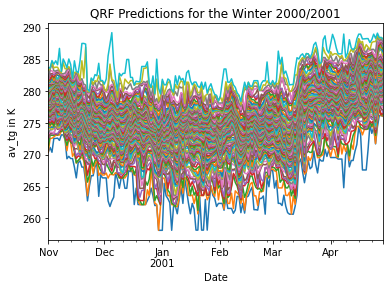

In [16]:
# For simplicity, the first predicted winter is plotted for a plausibility check.
start_winter = datetime(start_years_of_winter[0], config['start_month_winter'], config['start_day_winter'])
end_winter = datetime(start_years_of_winter[1], config['end_month_winter'], config['end_day_winter'])
days_of_winter = ((end_winter-start_winter).days)+1

df_predictions.iloc[0:days_of_winter-1].plot(x='time', legend=False)
plt.xlabel('Date')
plt.ylabel(config['ground_truth']+' in '+config['unit_of_ground_truth_and_prediction'])
plt.title('QRF Predictions for the Winter '+str(config['start_year_of_first_winter'])+'/'+str(config['start_year_of_first_winter']+1))
plt.savefig(config['PATH_predictions']+'QRF_predictions_'+config['ground_truth']+'_'+config['location_ground_truth']+'_input_'+config['input_data']+'_'+config['location_input']+'_lead_'+str(config['lead_time'])+'d_winter_'+str(config['start_year_of_first_winter'])+'_'+str(config['start_year_of_first_winter']+1)+'.png', bbox_inches='tight')

In [17]:
# End of Program